In [6]:
import uproot
import numpy as np
import skhep_testdata, uproot
import awkward as ak
import particle
from hepunits import GeV
import vector
import matplotlib.pyplot as plt

In [21]:
file_names = ["nano_100_0p25_0p02.root", "nano_800_0p25_0p0025.root", "nano_1000_0p25_0p002.root", "nano_1000_0p25_2p0.root", "nano_1000_5p0_0p04.root"]


branches_dict = {}

for file_name in file_names:

    with uproot.open(file_name) as temp_file:
        tree = temp_file['Events']
        branches = tree.arrays(filter_name=["Muon_*", "Electron_*", "GenPart_*"])

    #Build Vectors
    muon = vector.zip({"pt": branches['Muon_pt'], "eta": branches['Muon_eta'], "phi": branches['Muon_phi'], "mass": branches['Muon_mass'], "looseId": branches['Muon_looseId']})
    electron_p4 = vector.zip({"pt": branches['Electron_pt'], "eta": branches['Electron_eta'], "phi": branches['Electron_phi'], "mass": branches['Electron_mass']})
    gen = vector.zip({"pt": branches['GenPart_pt'], "eta": branches['GenPart_eta'], "phi": branches['GenPart_phi'], "mass": branches['GenPart_mass'], "id": branches['GenPart_pdgId'], "status": branches['GenPart_status']}) 

    #Apply masks
    is_electron = (abs(gen.id) == 11) & (gen.status == 1)
    is_muon = (abs(gen.id) == 13) & (gen.status == 1)
    
    gen_electrons = gen[is_electron]
    gen_muons = gen[is_muon]

    correct_electron_pair = ak.sum(gen_electrons.id, axis=1) == 0
    correct_muon_pair = ak.sum(gen_muons.id, axis=1) == 0

    id_mask = (is_electron | is_muon)
    event_mask = (ak.num(gen_electrons) == 2) & (ak.num(gen_muons) == 2) & correct_electron_pair & correct_muon_pair
    
    gen_p4 = gen[id_mask]
    emu_gen_p4 = gen_p4[event_mask]

    #Calculate pairs.
    e_pair = gen_electrons[event_mask][:,0] + gen_electrons[event_mask][:,1]
    mu_pair = gen_muons[event_mask][:,0] + gen_muons[event_mask][:,1]
    bound_state = e_pair + mu_pair

    # Save the processed data into the dictionary under the file's name
    branches_dict[file_name] = {
        "e_pair": e_pair,
        "mu_pair": mu_pair,
        "bound_state": bound_state
    }
    
    #temp_file = uproot.open(file_name)
    #tree = temp_file['Events']
    #branches_dict[file_name] = tree.arrays()


#branches = branches_dict[file_names[0]] #store the data from the last file into the branches variable

In [14]:
#muon = vector.zip({"pt": branches['Muon_pt'],
                      #"eta": branches['Muon_eta'],
                      #"phi": branches['Muon_phi'],
                      #"mass": branches['Muon_mass'],
                      #"looseId": branches['Muon_looseId']})

#electron_p4 = vector.zip({"pt": branches['Electron_pt'],
                      #"eta": branches['Electron_eta'],
                      #"phi": branches['Electron_phi'],
                      #"mass": branches['Electron_mass']})

#gen = vector.zip({"pt": branches['GenPart_pt'],
                      #"eta": branches['GenPart_eta'],
                      #"phi": branches['GenPart_phi'],
                      #"mass": branches['GenPart_mass'],
                      # "id": branches['GenPart_pdgId'],
                      # "status": branches['GenPart_status']})

In [15]:
#Apply quality cuts to muons (could add more here)
good_muon_mask = (muon.pt > 100) & (muon.looseId == True) #muon level mask

#Apply the mask
good_muons = muon[good_muon_mask]

#Select events with at least two good muons
two_muons_mask = ak.count(good_muons.pt,1) >= 2 #event level mask
two_muons_p4 = good_muons[two_muons_mask]

first_muon_p4 = two_muons_p4[:, 0]
second_muon_p4 = two_muons_p4[:, 1]
muon_sum_p4 = first_muon_p4 + second_muon_p4 #event level quantity

two_electrons_mask = ak.count(electron_p4.pt,1) >= 2 #event level mask
two_electrons_p4 = electron_p4[two_electrons_mask]
first_electron_p4 = two_electrons_p4[:, 0]
second_electron_p4 = two_electrons_p4[:, 1]
electron_sum_p4 = first_electron_p4 + second_electron_p4 #event level quantity


#plt.hist(muon_sum_p4.mass, bins=50, range=(0, 6), color='red', label = "Muon", histtype='step',density=True)
#plt.hist(electron_sum_p4.mass, bins=50, range=(0, 6), color='blue', label = "Electron", histtype='step',density=True)


#plt.xlabel('Invariant mass (GeV)')
#plt.ylabel('A.U.')
#plt.title('Invariant mass of lepton pair')
#plt.legend(loc = 'upper right')

In [16]:
#is_electron = (abs(gen.id) == 11) & (gen.status == 1)
#is_muon = (abs(gen.id) == 13) & (gen.status == 1)
#gen_electrons = gen[is_electron]
#gen_muons = gen[is_muon]

#correct_electron_pair = ak.sum(gen_electrons.id, axis=1) == 0
#correct_muon_pair = ak.sum(gen_muons.id, axis=1) == 0

#id_mask = (is_electron | is_muon)
#event_mask = (ak.num(gen_electrons) == 2) & (ak.num(gen_muons) == 2) & correct_electron_pair & correct_muon_pair
#gen_p4=gen[id_mask]
#emu_gen_p4=gen_p4[event_mask]

#add correct_pair and event_mask attributes
#mu_pair=gen_muons[:,0]+gen_muons[:,1]
#e_pair=gen_electrons[:,0]+gen_electrons[:,1]

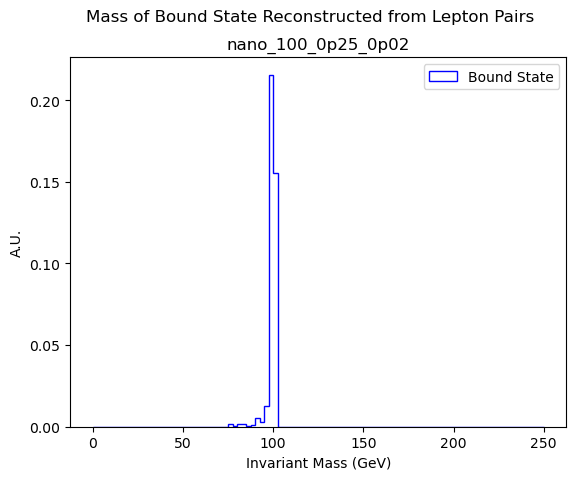

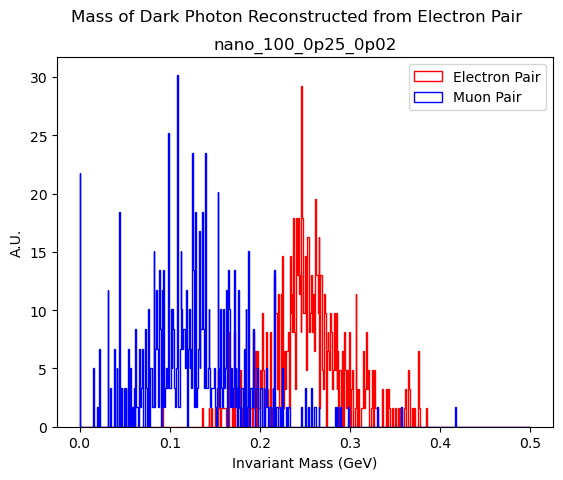

In [30]:
target_file = branches_dict["nano_100_0p25_0p02.root"]

plt.hist(target_file["bound_state"].mass, bins=100, range=(0, 250), color='blue', label = "Bound State", histtype='step',density=True)
#The reconstructed mass of the electron pair and muon pair is greater than the sum of its parts, because the calculation
#doesn't simply add up the two pairs' invariant masses. It accounts for the angle of separation and momenta of the 
#pairs as they are detected in the calorimeter to calculate the original mass of the bound state.

plt.xlabel('Invariant Mass (GeV)')
plt.ylabel('A.U.')
plt.suptitle('Mass of Bound State Reconstructed from Lepton Pairs')
plt.title('nano_100_0p25_0p02')
plt.legend(loc = 'upper right')
plt.show()

#Plotting the mass of just the gen electron pair, reconstructed as one of the 'Dark Photons'
#Both dark photons are practically indistinguishable and notably, they have significantly less mass than the bound state.
plt.hist(target_file["e_pair"].mass, bins=500, range=(0, 0.5), color='red', label = "Electron Pair", histtype='step',density=True)
plt.hist(target_file["mu_pair"].mass, bins=500, range=(0, 0.5), color='blue', label = "Muon Pair", histtype='step',density=True)

plt.xlabel('Invariant Mass (GeV)')
plt.ylabel('A.U.')
plt.suptitle('Mass of Dark Photon Reconstructed from Electron Pair')
plt.title('nano_100_0p25_0p02')
plt.legend(loc = 'upper right')
plt.show()

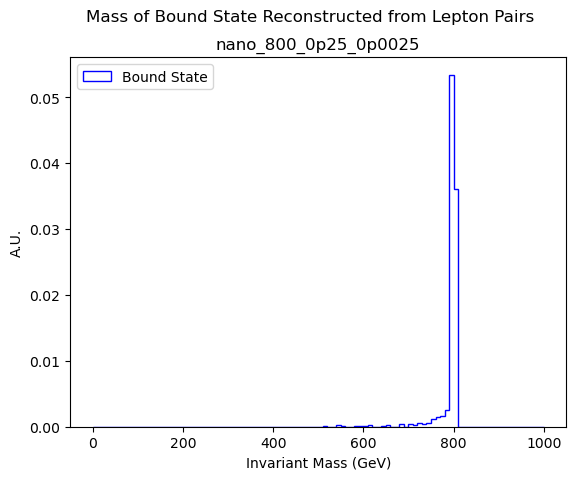

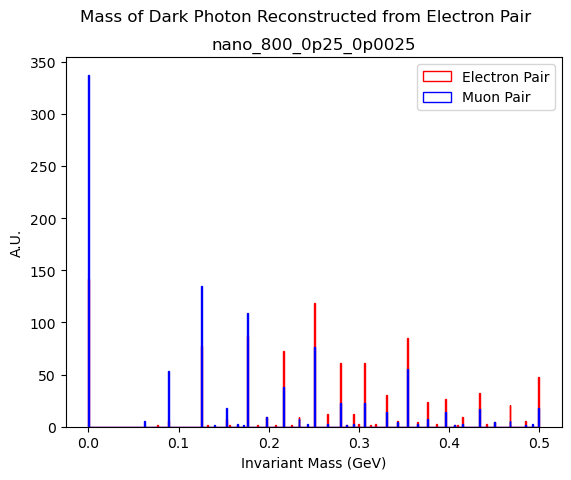

In [35]:
target_file = branches_dict["nano_800_0p25_0p0025.root"]

plt.hist(target_file["bound_state"].mass, bins=100, range=(0, 1000), color='blue', label = "Bound State", histtype='step',density=True)
#The reconstructed mass of the electron pair and muon pair is greater than the sum of its parts, because the calculation
#doesn't simply add up the two pairs' invariant masses. It accounts for the angle of separation and momenta of the 
#pairs as they are detected in the calorimeter to calculate the original mass of the bound state.

plt.xlabel('Invariant Mass (GeV)')
plt.ylabel('A.U.')
plt.suptitle('Mass of Bound State Reconstructed from Lepton Pairs')
plt.title('nano_800_0p25_0p0025')
plt.legend(loc = 'upper left')
plt.show()

#Plotting the mass of just the gen electron pair, reconstructed as one of the 'Dark Photons'
#Both dark photons are practically indistinguishable and notably, they have significantly less mass than the bound state.
plt.hist(target_file["e_pair"].mass, bins=500, range=(0, 0.5), color='red', label = "Electron Pair", histtype='step',density=True)
plt.hist(target_file["mu_pair"].mass, bins=500, range=(0, 0.5), color='blue', label = "Muon Pair", histtype='step',density=True)

plt.xlabel('Invariant Mass (GeV)')
plt.ylabel('A.U.')
plt.suptitle('Mass of Dark Photon Reconstructed from Electron Pair')
plt.title('nano_800_0p25_0p0025')
plt.legend(loc = 'upper right')
plt.show()

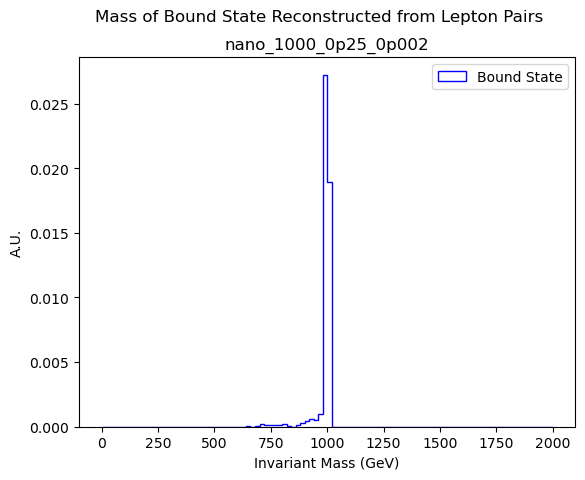

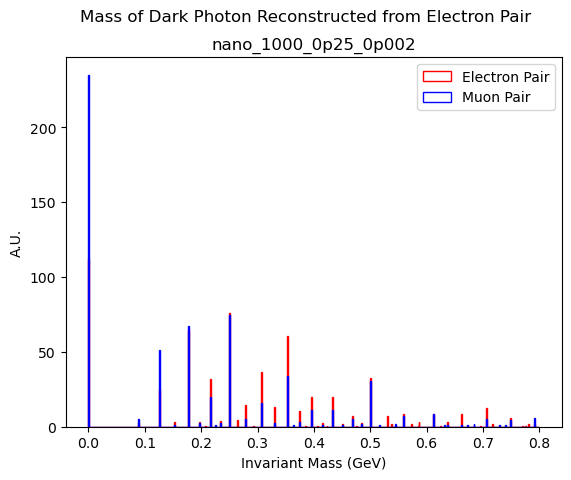

In [33]:
target_file = branches_dict["nano_1000_0p25_0p002.root"]

plt.hist(target_file["bound_state"].mass, bins=100, range=(0, 2000), color='blue', label = "Bound State", histtype='step',density=True)
#The reconstructed mass of the electron pair and muon pair is greater than the sum of its parts, because the calculation
#doesn't simply add up the two pairs' invariant masses. It accounts for the angle of separation and momenta of the 
#pairs as they are detected in the calorimeter to calculate the original mass of the bound state.

plt.xlabel('Invariant Mass (GeV)')
plt.ylabel('A.U.')
plt.suptitle('Mass of Bound State Reconstructed from Lepton Pairs')
plt.title('nano_1000_0p25_0p002')
plt.legend(loc = 'upper right')
plt.show()

#Plotting the mass of just the gen electron pair, reconstructed as one of the 'Dark Photons'
#Both dark photons are practically indistinguishable and notably, they have significantly less mass than the bound state.
plt.hist(target_file["e_pair"].mass, bins=500, range=(0, 0.8), color='red', label = "Electron Pair", histtype='step',density=True)
plt.hist(target_file["mu_pair"].mass, bins=500, range=(0, 0.8), color='blue', label = "Muon Pair", histtype='step',density=True)

plt.xlabel('Invariant Mass (GeV)')
plt.ylabel('A.U.')
plt.suptitle('Mass of Dark Photon Reconstructed from Electron Pair')
plt.title('nano_1000_0p25_0p002')
plt.legend(loc = 'upper right')
plt.show()

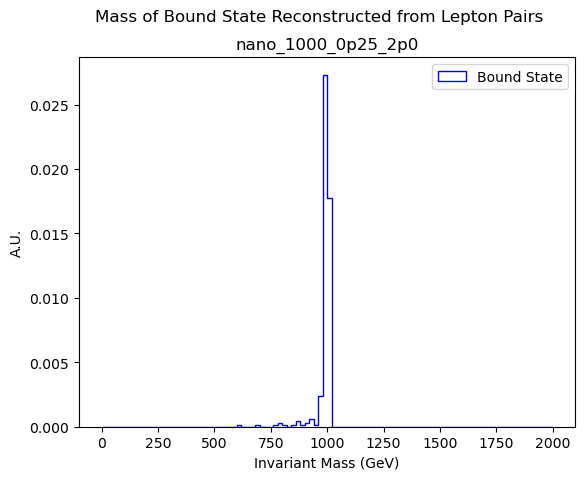

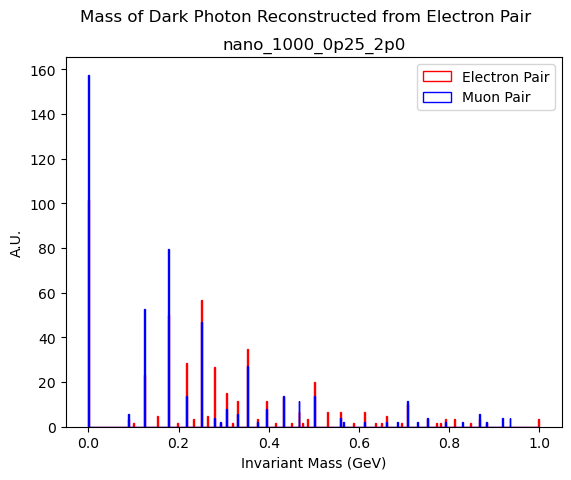

In [37]:
target_file = branches_dict["nano_1000_0p25_2p0.root"]

plt.hist(target_file["bound_state"].mass, bins=100, range=(0, 2000), color='blue', label = "Bound State", histtype='step',density=True)
#The reconstructed mass of the electron pair and muon pair is greater than the sum of its parts, because the calculation
#doesn't simply add up the two pairs' invariant masses. It accounts for the angle of separation and momenta of the 
#pairs as they are detected in the calorimeter to calculate the original mass of the bound state.

plt.xlabel('Invariant Mass (GeV)')
plt.ylabel('A.U.')
plt.suptitle('Mass of Bound State Reconstructed from Lepton Pairs')
plt.title('nano_1000_0p25_2p0')
plt.legend(loc = 'upper right')
plt.show()

#Plotting the mass of just the gen electron pair, reconstructed as one of the 'Dark Photons'
#Both dark photons are practically indistinguishable and notably, they have significantly less mass than the bound state.
plt.hist(target_file["e_pair"].mass, bins=500, range=(0, 1), color='red', label = "Electron Pair", histtype='step',density=True)
plt.hist(target_file["mu_pair"].mass, bins=500, range=(0, 1), color='blue', label = "Muon Pair", histtype='step',density=True)

plt.xlabel('Invariant Mass (GeV)')
plt.ylabel('A.U.')
plt.suptitle('Mass of Dark Photon Reconstructed from Electron Pair')
plt.title('nano_1000_0p25_2p0')
plt.legend(loc = 'upper right')
plt.show()

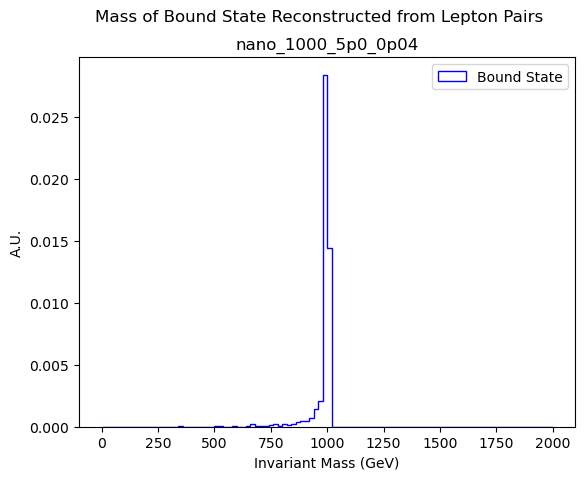

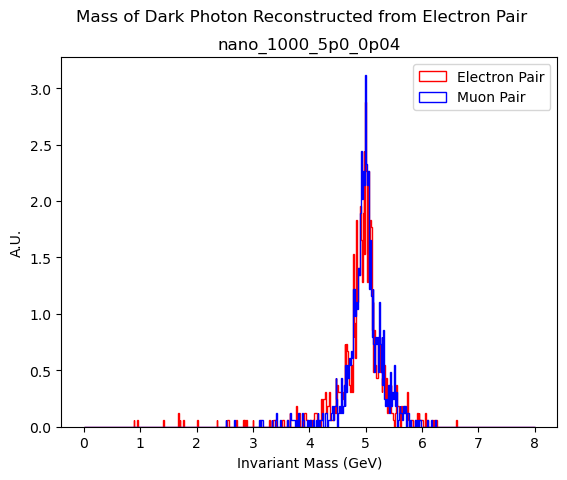

In [38]:
target_file = branches_dict["nano_1000_5p0_0p04.root"]

plt.hist(target_file["bound_state"].mass, bins=100, range=(0, 2000), color='blue', label = "Bound State", histtype='step',density=True)
#The reconstructed mass of the electron pair and muon pair is greater than the sum of its parts, because the calculation
#doesn't simply add up the two pairs' invariant masses. It accounts for the angle of separation and momenta of the 
#pairs as they are detected in the calorimeter to calculate the original mass of the bound state.

plt.xlabel('Invariant Mass (GeV)')
plt.ylabel('A.U.')
plt.suptitle('Mass of Bound State Reconstructed from Lepton Pairs')
plt.title('nano_1000_5p0_0p04')
plt.legend(loc = 'upper right')
plt.show()

#Plotting the mass of just the gen electron pair, reconstructed as one of the 'Dark Photons'
#Both dark photons are practically indistinguishable and notably, they have significantly less mass than the bound state.
plt.hist(target_file["e_pair"].mass, bins=500, range=(0, 8), color='red', label = "Electron Pair", histtype='step',density=True)
plt.hist(target_file["mu_pair"].mass, bins=500, range=(0, 8), color='blue', label = "Muon Pair", histtype='step',density=True)

plt.xlabel('Invariant Mass (GeV)')
plt.ylabel('A.U.')
plt.suptitle('Mass of Dark Photon Reconstructed from Electron Pair')
plt.title('nano_1000_5p0_0p04')
plt.legend(loc = 'upper right')
plt.show()

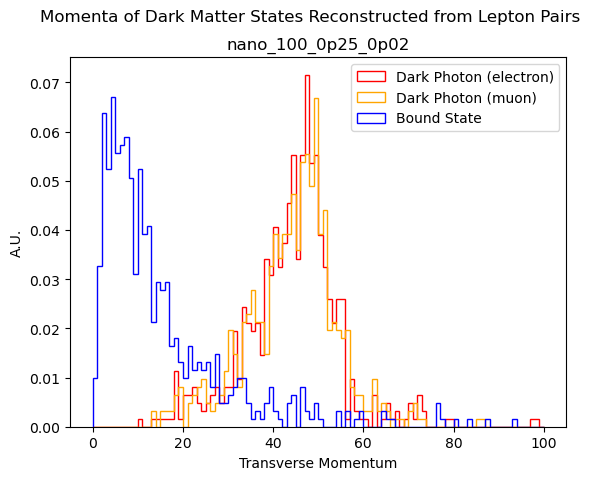

In [43]:
target_file = branches_dict["nano_100_0p25_0p02.root"]

plt.hist(target_file["e_pair"].pt, bins=100, range=(0, 100), color='red', label = "Dark Photon (electron)", histtype='step',density=True)
plt.hist(target_file["mu_pair"].pt, bins=100, range=(0, 100), color='orange', label = "Dark Photon (muon)", histtype='step',density=True)
plt.hist(target_file["bound_state"].pt, bins=100, range=(0, 100), color='blue', label = "Bound State", histtype='step',density=True)
#in deliverable:talk about mass of electrons vs mass of photons vs mass of bound state. m_e and m_mu are both small because its invariant mass, but mass uses reconstructed formula that takes into account angle between offshoot particles and the momenta of the particles.

plt.xlabel('Transverse Momentum')
plt.ylabel('A.U.')
plt.suptitle('Momenta of Dark Matter States Reconstructed from Lepton Pairs')
plt.title('nano_100_0p25_0p02')
plt.legend(loc = 'upper right')
plt.show()

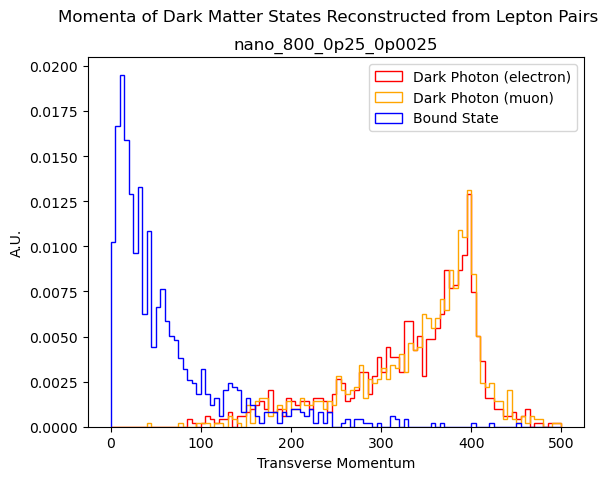

In [46]:
target_file = branches_dict["nano_800_0p25_0p0025.root"]

plt.hist(target_file["e_pair"].pt, bins=100, range=(0, 500), color='red', label = "Dark Photon (electron)", histtype='step',density=True)
plt.hist(target_file["mu_pair"].pt, bins=100, range=(0, 500), color='orange', label = "Dark Photon (muon)", histtype='step',density=True)
plt.hist(target_file["bound_state"].pt, bins=100, range=(0,500), color='blue', label = "Bound State", histtype='step',density=True)
#in deliverable:talk about mass of electrons vs mass of photons vs mass of bound state. m_e and m_mu are both small because its invariant mass, but mass uses reconstructed formula that takes into account angle between offshoot particles and the momenta of the particles.

plt.xlabel('Transverse Momentum')
plt.ylabel('A.U.')
plt.suptitle('Momenta of Dark Matter States Reconstructed from Lepton Pairs')
plt.title('nano_800_0p25_0p0025')
plt.legend(loc = 'upper right')
plt.show()

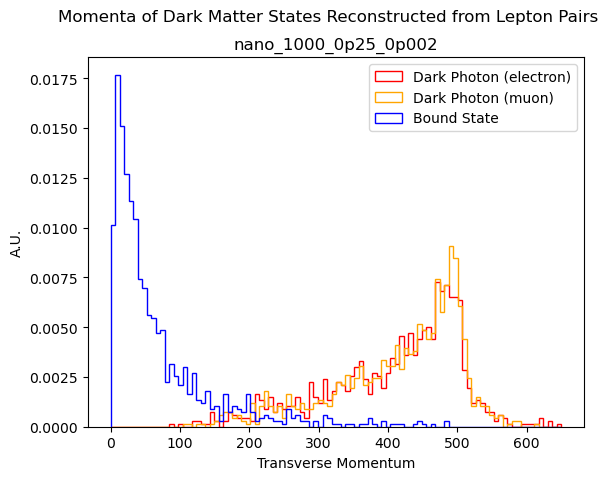

In [25]:
target_file = branches_dict["nano_1000_0p25_0p002.root"]

plt.hist(target_file["e_pair"].pt, bins=100, range=(0, 650), color='red', label = "Dark Photon (electron)", histtype='step',density=True)
plt.hist(target_file["mu_pair"].pt, bins=100, range=(0, 650), color='orange', label = "Dark Photon (muon)", histtype='step',density=True)
plt.hist(target_file["bound_state"].pt, bins=100, range=(0, 650), color='blue', label = "Bound State", histtype='step',density=True)
#in deliverable:talk about mass of electrons vs mass of photons vs mass of bound state. m_e and m_mu are both small because its invariant mass, but mass uses reconstructed formula that takes into account angle between offshoot particles and the momenta of the particles.

plt.xlabel('Transverse Momentum')
plt.ylabel('A.U.')
plt.suptitle('Momenta of Dark Matter States Reconstructed from Lepton Pairs')
plt.title('nano_1000_0p25_0p002')
plt.legend(loc = 'upper right')
plt.show()

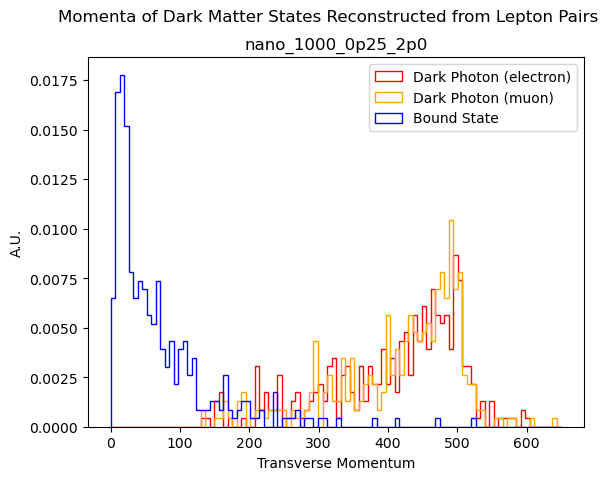

In [47]:
target_file = branches_dict["nano_1000_0p25_2p0.root"]

plt.hist(target_file["e_pair"].pt, bins=100, range=(0, 650), color='red', label = "Dark Photon (electron)", histtype='step',density=True)
plt.hist(target_file["mu_pair"].pt, bins=100, range=(0, 650), color='orange', label = "Dark Photon (muon)", histtype='step',density=True)
plt.hist(target_file["bound_state"].pt, bins=100, range=(0, 650), color='blue', label = "Bound State", histtype='step',density=True)
#in deliverable:talk about mass of electrons vs mass of photons vs mass of bound state. m_e and m_mu are both small because its invariant mass, but mass uses reconstructed formula that takes into account angle between offshoot particles and the momenta of the particles.

plt.xlabel('Transverse Momentum')
plt.ylabel('A.U.')
plt.suptitle('Momenta of Dark Matter States Reconstructed from Lepton Pairs')
plt.title('nano_1000_0p25_2p0')
plt.legend(loc = 'upper right')
plt.show()

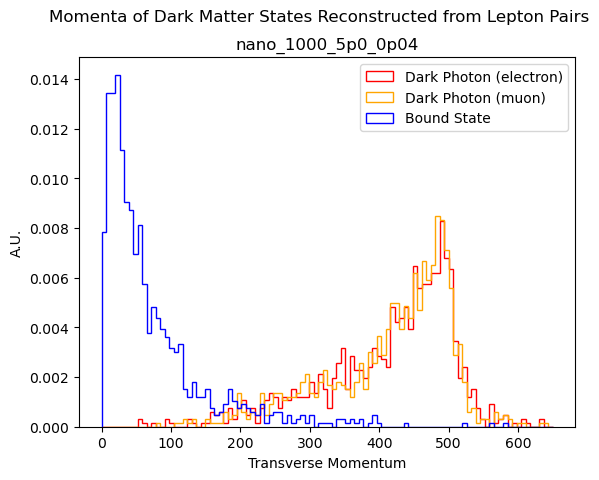

In [48]:
target_file = branches_dict["nano_1000_5p0_0p04.root"]

plt.hist(target_file["e_pair"].pt, bins=100, range=(0, 650), color='red', label = "Dark Photon (electron)", histtype='step',density=True)
plt.hist(target_file["mu_pair"].pt, bins=100, range=(0, 650), color='orange', label = "Dark Photon (muon)", histtype='step',density=True)
plt.hist(target_file["bound_state"].pt, bins=100, range=(0, 650), color='blue', label = "Bound State", histtype='step',density=True)
#in deliverable:talk about mass of electrons vs mass of photons vs mass of bound state. m_e and m_mu are both small because its invariant mass, but mass uses reconstructed formula that takes into account angle between offshoot particles and the momenta of the particles.

plt.xlabel('Transverse Momentum')
plt.ylabel('A.U.')
plt.suptitle('Momenta of Dark Matter States Reconstructed from Lepton Pairs')
plt.title('nano_1000_5p0_0p04')
plt.legend(loc = 'upper right')
plt.show()

In [ ]:
#all gen below
#Bound State mass for different files cha-ching
#dark photon mass zoomed in to see either .25 or 5 for files cha-ching
#Bound state Momenta for different files cha-ching
#dark photon momenta for different files cha-ching

#actually separate above into electron and muon pt, (highest = leading) electron 0 in array is highest pt (hardest plot)
#still needs to be done ^

#then start recon particles